# 03 Major Index Classical Machine Learning Rolling Windows

This notebook tunes and evaluates the classical machine-learning models on the shared rolling-window cases.

## Forecast Design
- Target: one-step-ahead index level
- Inputs: 8 technical indicators only
- Tune on windows with `2022` test-point dates
- Refit the selected configuration on each evaluation window in `2023-2026`
- Log the full path, while plots separate the tuning segment from the pure-test segment

## Models And Fixed Grids
- `SVR`: `C=[0.1, 0.5, 1.0, 10.0]`, `epsilon=[0.01, 0.05, 0.1]`, `gamma=['scale', 0.03, 0.1]` -> `36` configs
- `RandomForest`: `n_estimators=[100, 300, 500]`, `max_depth=[None, 4, 8]`, `min_samples_leaf=[1, 2]`, `max_features=['sqrt', 0.8]` -> `36` configs
- `GradientBoosting`: `n_estimators=[100, 300, 500]`, `learning_rate=[0.03, 0.05, 0.1]`, `max_depth=[2, 3]`, `subsample=[0.8, 1.0]` -> `36` configs
- `XGBoost`: `n_estimators=[100, 300, 500]`, `learning_rate=[0.03, 0.05, 0.1]`, `max_depth=[2, 3]`, `subsample=[0.8, 1.0]` -> `36` configs


In [1]:
from __future__ import annotations

import hashlib
import json
import time
from contextlib import contextmanager
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from sklearn.svm import SVR
from xgboost import XGBRegressor


def resolve_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Run this notebook from the project root or its notebooks directory.")


PROJECT_ROOT = resolve_project_root()
PIPELINE_BUNDLE_PATH = PROJECT_ROOT / "outputs" / "01_major_index_sliding_window_pipeline" / "major_index_sliding_window_bundle.joblib"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "03_major_index_classical_ml_rolling"
LOG_DIR = OUTPUT_ROOT / "rolling_logs"
PREDICTIONS_DIR = OUTPUT_ROOT / "predictions"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
for directory in [OUTPUT_ROOT, LOG_DIR, PREDICTIONS_DIR, TABLE_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_close"
FEATURE_COLS = ["rsi14", "macd_hist", "bb_z20", "roc10", "vol20", "sma10_gap", "atr14_pct", "williams_r14"]
NOTEBOOK_TAG = "03_major_index_classical_ml_rolling"
ALL_LOGS_PATH = OUTPUT_ROOT / "all_rolling_logs.csv"
SCORES_SUMMARY_PATH = TABLE_DIR / "scores_summary.csv"
BEST_CONFIGS_PATH = TABLE_DIR / "best_configs.csv"
MODEL_SUMMARY_PATH = TABLE_DIR / "model_summary.csv"
GRID_PROFILE_PATH = TABLE_DIR / "grid_profile.csv"
TIMING_SUMMARY_PATH = TABLE_DIR / "timing_summary.csv"

TIMING_ROWS: list[dict] = []
FORCE_FRESH_RUN = False
FLUSH_EVERY_N_ROWS = 1
MODEL_SELECTION_SCOPE = "tuning_windows_only"
EXPORT_PREDICTION_SCOPE = "all_logged"  # all_logged | pure_test_only
PLOT_PREDICTION_SCOPE = "all_logged"  # all_logged | pure_test_only
PLOT_SHADE_TUNING_PERIOD = True
HP_TUNING_LABEL = "Used for HP tuning"
PURE_TEST_LABEL = "Pure test period"
PURE_TEST_START_DATE = "2023-01-01"


In [2]:
@contextmanager
def timed_step(step_name: str):
    start = time.perf_counter()
    yield
    elapsed_seconds = time.perf_counter() - start
    TIMING_ROWS.append({"step": step_name, "elapsed_seconds": elapsed_seconds})
    print(f"[TIMER] {step_name}: {elapsed_seconds:.2f}s")


def load_case_bundle(path: Path = PIPELINE_BUNDLE_PATH) -> dict:
    bundle = joblib.load(path)
    return bundle["case_bundle"]


LOG_DATE_COLS = ["train_end_date", "test_reference_date", "test_target_date"]
WINDOW_KEY_COLS = ["case_key", "model_name", "config_index", "run_stage", "window_id"]


def reset_output_targets() -> None:
    for path in [ALL_LOGS_PATH, SCORES_SUMMARY_PATH, BEST_CONFIGS_PATH, MODEL_SUMMARY_PATH, TIMING_SUMMARY_PATH]:
        if path.exists():
            path.unlink()
    for directory in [LOG_DIR, PREDICTIONS_DIR]:
        for csv_path in directory.glob("*.csv"):
            csv_path.unlink()
    for png_path in FIG_DIR.glob("*.png"):
        png_path.unlink()


def append_frame(path: Path, frame: pd.DataFrame) -> None:
    if frame is None or frame.empty:
        return
    frame.to_csv(path, mode="a", header=not path.exists(), index=False)


def load_progress_frame(path: Path = ALL_LOGS_PATH) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    frame = pd.read_csv(path)
    for col in LOG_DATE_COLS:
        if col in frame.columns:
            frame[col] = pd.to_datetime(frame[col], errors="coerce")
    if "is_tuning_window" in frame.columns:
        frame["is_tuning_window"] = frame["is_tuning_window"].astype(str).str.lower().eq("true")
    if all(col in frame.columns for col in WINDOW_KEY_COLS):
        frame = frame.drop_duplicates(subset=WINDOW_KEY_COLS, keep="last").reset_index(drop=True)
    return frame


def window_result_key(case_key: str, model_name: str, config_index: int, run_stage: str, window_id: int) -> tuple[str, str, int, str, int]:
    return (str(case_key), str(model_name), int(config_index), str(run_stage), int(window_id))


def completed_window_keys(frame: pd.DataFrame, run_stage: str | None = None) -> set[tuple[str, str, int, str, int]]:
    if frame.empty or "status" not in frame.columns:
        return set()
    completed = frame.loc[frame["status"].eq("completed")].copy()
    if run_stage is not None and "run_stage" in completed.columns:
        completed = completed.loc[completed["run_stage"].eq(run_stage)].copy()
    if completed.empty:
        return set()
    return {
        window_result_key(
            row["case_key"],
            row["model_name"],
            int(row["config_index"]),
            row["run_stage"],
            int(row["window_id"]),
        )
        for _, row in completed.iterrows()
    }


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = np.asarray(y_true, dtype=float)[mask]
    yp = np.asarray(y_pred, dtype=float)[mask]
    if len(yt) == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "n_points": 0}
    return {
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "R2": float(r2_score(yt, yp)) if len(yt) > 1 else np.nan,
        "n_points": int(len(yt)),
    }


def add_error_columns(frame: pd.DataFrame) -> pd.DataFrame:
    if frame is None or len(frame) == 0:
        return frame.copy() if isinstance(frame, pd.DataFrame) else pd.DataFrame()
    enriched = frame.copy()
    enriched["error_points"] = enriched["predicted_close"] - enriched["actual_close"]
    enriched["error_pct"] = np.where(
        np.isfinite(enriched["actual_close"]) & (np.abs(enriched["actual_close"]) > 1e-12),
        100.0 * enriched["error_points"] / enriched["actual_close"],
        np.nan,
    )
    enriched["abs_error_pct"] = np.abs(enriched["error_pct"])
    return enriched


def summarize_config(config: dict) -> str:
    parts = []
    for key, value in config.items():
        parts.append(f"{key}={value}")
    return " ".join(parts)


def config_key(model_name: str, config: dict) -> str:
    payload = json.dumps({"model": model_name, **config}, sort_keys=True)
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:16]


MODEL_GRID_SPECS = {
    "SVR": {
        "C": [0.1, 0.5, 2.5, 10.0],
        "epsilon": [0.01, 0.03, 0.1],
        "gamma": [0.01, 0.03, 0.1],
    },
    "RandomForest": {
        "n_estimators": [100, 300, 500],
        "max_depth": [None, 4, 8],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.8],
    },
    "GradientBoosting": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.04, 0.08, 0.16],
        "max_depth": [2, 3],
        "subsample": [0.8, 1.0],
    },
    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.04, 0.08, 0.16],
        "max_depth": [2, 3],
        "subsample": [0.8, 1.0],
    },
}


def format_grid_spec(spec: dict) -> str:
    return " | ".join(f"{key}={list(values)}" for key, values in spec.items())


MODEL_GRIDS = {model_name: list(ParameterGrid(spec)) for model_name, spec in MODEL_GRID_SPECS.items()}
GRID_PROFILE = pd.DataFrame(
    [
        {
            "model_name": model_name,
            "n_configs": int(len(configs)),
            "grid_spec": format_grid_spec(MODEL_GRID_SPECS[model_name]),
        }
        for model_name, configs in MODEL_GRIDS.items()
    ]
).sort_values("model_name").reset_index(drop=True)


def fit_predict_window(model_name: str, config: dict, train_df: pd.DataFrame, test_df: pd.DataFrame) -> float:
    X_tr = train_df[FEATURE_COLS].to_numpy(dtype=float)
    X_te = test_df[FEATURE_COLS].to_numpy(dtype=float)
    y_tr = train_df[TARGET_COL].to_numpy(dtype=float)

    if model_name == "SVR":
        x_scaler = StandardScaler().fit(X_tr)
        y_scaler = StandardScaler().fit(y_tr.reshape(-1, 1))
        X_tr_ready = x_scaler.transform(X_tr)
        X_te_ready = x_scaler.transform(X_te)
        y_tr_ready = y_scaler.transform(y_tr.reshape(-1, 1)).ravel()
        model = SVR(kernel="rbf", C=float(config["C"]), epsilon=float(config["epsilon"]), gamma=config["gamma"])
        model.fit(X_tr_ready, y_tr_ready)
        pred_scaled = model.predict(X_te_ready).reshape(-1, 1)
        return float(y_scaler.inverse_transform(pred_scaled).ravel()[0])

    if model_name == "RandomForest":
        model = RandomForestRegressor(
            n_estimators=int(config["n_estimators"]),
            max_depth=None if config["max_depth"] is None else int(config["max_depth"]),
            min_samples_leaf=int(config["min_samples_leaf"]),
            max_features=config["max_features"],
            random_state=42,
        )
    elif model_name == "GradientBoosting":
        model = GradientBoostingRegressor(
            n_estimators=int(config["n_estimators"]),
            learning_rate=float(config["learning_rate"]),
            max_depth=int(config["max_depth"]),
            subsample=float(config["subsample"]),
            random_state=42,
        )
    elif model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=int(config["n_estimators"]),
            max_depth=int(config["max_depth"]),
            learning_rate=float(config["learning_rate"]),
            subsample=float(config["subsample"]),
            objective="reg:squarederror",
            random_state=42,
            verbosity=0,
            n_jobs=1,
        )
    else:
        raise ValueError(model_name)

    model.fit(X_tr, y_tr)
    return float(model.predict(X_te).reshape(-1)[0])


def run_manifest_for_config(
    *,
    case_key: str,
    index_key: str,
    window_size: int,
    frame: pd.DataFrame,
    manifest: pd.DataFrame,
    model_name: str,
    config_index: int,
    config: dict,
    run_stage: str,
    progress_bar=None,
    completed_keys: set[tuple[str, str, int, str, int]] | None = None,
    flush_path: Path | None = None,
    flush_every: int = FLUSH_EVERY_N_ROWS,
) -> list[dict]:
    rows = []
    buffer: list[dict] = []
    cfg_key = config_key(model_name, config)
    cfg_summary = summarize_config(config)
    cfg_json = json.dumps(config, sort_keys=True)
    for _, meta in manifest.iterrows():
        unit_key = window_result_key(case_key, model_name, int(config_index), run_stage, int(meta["window_id"]))
        if completed_keys is not None and unit_key in completed_keys:
            continue

        train_df = frame.iloc[int(meta["start"]) : int(meta["start"]) + int(meta["train_rows"])].copy()
        test_df = frame.iloc[int(meta["end_exclusive"]) - int(meta["test_rows"]) : int(meta["end_exclusive"])].copy()
        y_true = float(test_df[TARGET_COL].iloc[-1])
        reference_close = float(test_df["reference_close"].iloc[-1])
        target_close = float(test_df["target_close"].iloc[-1])
        fit_start = time.perf_counter()
        status = "completed"
        error_message = ""
        y_pred = np.nan
        try:
            y_pred = fit_predict_window(model_name, config, train_df=train_df, test_df=test_df)
        except Exception as exc:
            status = "failed"
            error_message = f"{type(exc).__name__}: {exc}"
        fit_seconds = time.perf_counter() - fit_start
        row = {
            "case_key": case_key,
            "index_key": index_key,
            "window_size": window_size,
            "model_name": model_name,
            "config_index": int(config_index),
            "config_key": cfg_key,
            "config_summary": cfg_summary,
            "config_json": cfg_json,
            "run_stage": run_stage,
            "window_id": int(meta["window_id"]),
            "train_end_date": pd.Timestamp(meta["train_end_date"]),
            "test_reference_date": pd.Timestamp(meta["test_reference_date"]),
            "test_target_date": pd.Timestamp(meta["test_target_date"]),
            "is_tuning_window": bool(meta["is_tuning_window"]),
            "reference_close": reference_close,
            "target_close": target_close,
            "y_true": y_true,
            "y_pred": float(y_pred) if np.isfinite(y_pred) else np.nan,
            "actual_close": target_close if np.isfinite(target_close) else np.nan,
            "predicted_close": float(y_pred) if np.isfinite(y_pred) else np.nan,
            "fit_seconds": float(fit_seconds),
            "status": status,
            "error_message": error_message,
        }
        rows.append(row)
        buffer.append(row)
        if status == "completed" and completed_keys is not None:
            completed_keys.add(unit_key)
        if flush_path is not None and len(buffer) >= int(flush_every):
            append_frame(flush_path, finalize_logs(buffer))
            buffer = []
        if progress_bar is not None:
            progress_bar.update(1)
    if flush_path is not None and buffer:
        append_frame(flush_path, finalize_logs(buffer))
    return rows


def finalize_logs(rows: list[dict]) -> pd.DataFrame:
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame = frame.sort_values(["case_key", "model_name", "config_index", "window_id"]).reset_index(drop=True)
    return add_error_columns(frame)


def split_completed_logs(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    return frame.loc[frame["status"].eq("completed")].copy()



def build_scores_summary(logs: pd.DataFrame) -> pd.DataFrame:
    completed = split_completed_logs(logs)
    rows = []
    group_cols = ["case_key", "index_key", "window_size", "model_name", "config_index", "config_key", "config_summary"]
    for keys, group in completed.groupby(group_cols, dropna=False):
        tune = add_error_columns(group.loc[group["is_tuning_window"]].copy())
        eval_frame = add_error_columns(group.loc[~group["is_tuning_window"]].copy())
        m_tune = regression_metrics(tune["y_true"].to_numpy(dtype=float), tune["y_pred"].to_numpy(dtype=float))
        m_eval = regression_metrics(eval_frame["y_true"].to_numpy(dtype=float), eval_frame["y_pred"].to_numpy(dtype=float))
        tune_mean_close = float(tune["actual_close"].mean()) if len(tune) else np.nan
        eval_mean_close = float(eval_frame["actual_close"].mean()) if len(eval_frame) else np.nan
        rows.append(
            {
                "case_key": keys[0],
                "index_key": keys[1],
                "window_size": int(keys[2]),
                "model": keys[3],
                "config_index": int(keys[4]),
                "config_key": keys[5],
                "config_summary": keys[6],
                "config_json": group["config_json"].iloc[0],
                "tune_MAE": m_tune["MAE"],
                "tune_RMSE": m_tune["RMSE"],
                "tune_R2": m_tune["R2"],
                "tune_n": m_tune["n_points"],
                "tune_close_MAE": m_tune["MAE"],
                "tune_close_RMSE": m_tune["RMSE"],
                "tune_close_R2": m_tune["R2"],
                "tune_close_n": m_tune["n_points"],
                "tune_close_MAE_pct": 100.0 * m_tune["MAE"] / tune_mean_close if np.isfinite(tune_mean_close) and abs(tune_mean_close) > 1e-12 else np.nan,
                "tune_close_RMSE_pct": 100.0 * m_tune["RMSE"] / tune_mean_close if np.isfinite(tune_mean_close) and abs(tune_mean_close) > 1e-12 else np.nan,
                "tune_abs_error_pct_mean": float(tune["abs_error_pct"].mean()) if len(tune) else np.nan,
                "tune_error_pct_bias": float(tune["error_pct"].mean()) if len(tune) else np.nan,
                "tune_windows": int(len(tune)),
                "eval_MAE": m_eval["MAE"],
                "eval_RMSE": m_eval["RMSE"],
                "eval_R2": m_eval["R2"],
                "eval_n": m_eval["n_points"],
                "eval_close_MAE": m_eval["MAE"],
                "eval_close_RMSE": m_eval["RMSE"],
                "eval_close_R2": m_eval["R2"],
                "eval_close_n": m_eval["n_points"],
                "eval_close_MAE_pct": 100.0 * m_eval["MAE"] / eval_mean_close if np.isfinite(eval_mean_close) and abs(eval_mean_close) > 1e-12 else np.nan,
                "eval_close_RMSE_pct": 100.0 * m_eval["RMSE"] / eval_mean_close if np.isfinite(eval_mean_close) and abs(eval_mean_close) > 1e-12 else np.nan,
                "eval_abs_error_pct_mean": float(eval_frame["abs_error_pct"].mean()) if len(eval_frame) else np.nan,
                "eval_error_pct_bias": float(eval_frame["error_pct"].mean()) if len(eval_frame) else np.nan,
                "eval_windows": int(len(eval_frame)),
                "mean_fit_seconds": float(group["fit_seconds"].mean()),
                "metric_scope": "selection=one_step_index_level; presentation=index_level_and_relative_error",
                "target_definition": "one_step_index_level",
            }
        )
    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary
    return summary.sort_values(["case_key", "model", "config_index"]).reset_index(drop=True)



def select_best_configs(scores: pd.DataFrame) -> pd.DataFrame:
    picks = []
    for (case_key, model_name), group in scores.groupby(["case_key", "model"], as_index=False):
        group = group.dropna(subset=["tune_close_RMSE"]).copy()
        if group.empty:
            continue
        pick = group.sort_values(
            ["tune_close_RMSE", "tune_abs_error_pct_mean", "tune_close_MAE", "config_index"],
            ascending=[True, True, True, True],
            kind="stable",
        ).iloc[0]
        picks.append(pick.to_dict())
    picked = pd.DataFrame(picks)
    if picked.empty:
        return picked
    return picked.sort_values(["case_key", "model"]).reset_index(drop=True)


In [3]:
GRID_PROFILE.to_csv(GRID_PROFILE_PATH, index=False)
display(GRID_PROFILE)


with timed_step("tuning_ml_runs"):
    case_bundle = load_case_bundle()
    if FORCE_FRESH_RUN:
        reset_output_targets()

    existing_logs = load_progress_frame()
    completed_tuning = completed_window_keys(existing_logs, run_stage="tuning")
    tuning_total_full = 0
    for case in case_bundle.values():
        tuning_windows = int(case["window_manifest"]["is_tuning_window"].sum())
        tuning_total_full += tuning_windows * sum(len(configs) for configs in MODEL_GRIDS.values())
    tuning_total_pending = max(0, tuning_total_full - len(completed_tuning))

    with tqdm(total=tuning_total_pending, desc="ML tuning windows") as progress_bar:
        for case_key, case in case_bundle.items():
            frame = case["df"].copy().reset_index(drop=True)
            tuning_manifest = case["window_manifest"].loc[case["window_manifest"]["is_tuning_window"]].copy().reset_index(drop=True)

            for model_name, configs in MODEL_GRIDS.items():
                progress_bar.set_postfix_str(f"{case_key} | {model_name}", refresh=False)
                for config_index, config in enumerate(configs, start=1):
                    run_manifest_for_config(
                        case_key=case_key,
                        index_key=case["index_key"],
                        window_size=int(case["window_size"]),
                        frame=frame,
                        manifest=tuning_manifest,
                        model_name=model_name,
                        config_index=int(config_index),
                        config=config,
                        run_stage="tuning",
                        progress_bar=progress_bar,
                        completed_keys=completed_tuning,
                        flush_path=ALL_LOGS_PATH,
                    )

    tuning_logs = load_progress_frame()
    tuning_logs = tuning_logs.loc[tuning_logs["run_stage"].eq("tuning")].copy()


with timed_step("select_best_ml_configs"):
    tuning_scores = build_scores_summary(tuning_logs)
    selected_configs = select_best_configs(tuning_scores)
    tuning_scores.to_csv(SCORES_SUMMARY_PATH, index=False)
    selected_configs.to_csv(BEST_CONFIGS_PATH, index=False)


with timed_step("evaluation_ml_runs"):
    existing_logs = load_progress_frame()
    completed_eval = completed_window_keys(existing_logs, run_stage="evaluation")
    evaluation_total_pending = 0
    for _, selected_row in selected_configs.iterrows():
        case_key = selected_row["case_key"]
        case = case_bundle[case_key]
        eval_manifest = case["window_manifest"].loc[~case["window_manifest"]["is_tuning_window"]].copy().reset_index(drop=True)
        for window_id in eval_manifest["window_id"].tolist():
            unit_key = window_result_key(case_key, selected_row["model"], int(selected_row["config_index"]), "evaluation", int(window_id))
            if unit_key not in completed_eval:
                evaluation_total_pending += 1

    with tqdm(total=evaluation_total_pending, desc="ML evaluation windows") as progress_bar:
        for _, selected_row in selected_configs.iterrows():
            case_key = selected_row["case_key"]
            case = case_bundle[case_key]
            frame = case["df"].copy().reset_index(drop=True)
            eval_manifest = case["window_manifest"].loc[~case["window_manifest"]["is_tuning_window"]].copy().reset_index(drop=True)
            progress_bar.set_postfix_str(f"{case_key} | {selected_row['model']}", refresh=False)
            run_manifest_for_config(
                case_key=case_key,
                index_key=case["index_key"],
                window_size=int(case["window_size"]),
                frame=frame,
                manifest=eval_manifest,
                model_name=selected_row["model"],
                config_index=int(selected_row["config_index"]),
                config=json.loads(selected_row["config_json"]),
                run_stage="evaluation",
                progress_bar=progress_bar,
                completed_keys=completed_eval,
                flush_path=ALL_LOGS_PATH,
            )

    rolling_logs = load_progress_frame()
    if not rolling_logs.empty:
        rolling_logs = rolling_logs.sort_values(["case_key", "model_name", "config_index", "window_id"]).reset_index(drop=True)
        rolling_logs.to_csv(ALL_LOGS_PATH, index=False)
        for (case_key, model_name), group in rolling_logs.groupby(["case_key", "model_name"], as_index=False):
            group.to_csv(LOG_DIR / f"{case_key}_{model_name}.csv", index=False)

print("Selected configs from tuning stage")
display(selected_configs)
print("Rolling-log sample")
display(rolling_logs.head(20))


,model_name,n_configs,grid_spec
0,GradientBoosting,36,"n_estimators=[100, 300, 500] | learning_rate=[..."
1,RandomForest,36,"n_estimators=[100, 300, 500] | max_depth=[None..."
2,SVR,36,"C=[0.1, 0.5, 2.5, 10.0] | epsilon=[0.01, 0.03,..."
3,XGBoost,36,"n_estimators=[100, 300, 500] | learning_rate=[..."


ML tuning windows:   0%|          | 0/248832 [00:00<?, ?it/s]

[TIMER] tuning_ml_runs: 8251.06s
[TIMER] select_best_ml_configs: 1.15s


ML evaluation windows:   0%|          | 0/26016 [00:00<?, ?it/s]

[TIMER] evaluation_ml_runs: 421.06s
Selected configs from tuning stage


,case_key,index_key,window_size,model,config_index,config_key,config_summary,config_json,tune_MAE,tune_RMSE,...,eval_close_R2,eval_close_n,eval_close_MAE_pct,eval_close_RMSE_pct,eval_abs_error_pct_mean,eval_error_pct_bias,eval_windows,mean_fit_seconds,metric_scope,target_definition
0,DOWJONES_w10,DOWJONES,10,GradientBoosting,25,e8499da06c5ad0f3,learning_rate=0.16 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.16, ""max_depth"": 2, ""n_est...",416.065809,505.297897,...,NaN,0,NaN,NaN,NaN,NaN,0,0.011842,selection=one_step_index_level; presentation=i...,one_step_index_level
1,DOWJONES_w10,DOWJONES,10,RandomForest,7,cb02c1136792f10c,max_depth=None max_features=0.8 min_samples_le...,"{""max_depth"": null, ""max_features"": 0.8, ""min_...",415.938301,509.580876,...,NaN,0,NaN,NaN,NaN,NaN,0,0.028274,selection=one_step_index_level; presentation=i...,one_step_index_level
2,DOWJONES_w10,DOWJONES,10,SVR,34,cc4c82a5255cfd43,C=10.0 epsilon=0.1 gamma=0.01,"{""C"": 10.0, ""epsilon"": 0.1, ""gamma"": 0.01}",414.468973,520.232495,...,NaN,0,NaN,NaN,NaN,NaN,0,0.000562,selection=one_step_index_level; presentation=i...,one_step_index_level
3,DOWJONES_w10,DOWJONES,10,XGBoost,31,7d8dcd0460564cc4,learning_rate=0.16 max_depth=3 n_estimators=10...,"{""learning_rate"": 0.16, ""max_depth"": 3, ""n_est...",400.608138,505.121822,...,NaN,0,NaN,NaN,NaN,NaN,0,0.003862,selection=one_step_index_level; presentation=i...,one_step_index_level
4,DOWJONES_w20,DOWJONES,20,GradientBoosting,3,33f909e150dad66d,learning_rate=0.04 max_depth=2 n_estimators=30...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",422.983690,541.767224,...,NaN,0,NaN,NaN,NaN,NaN,0,0.035746,selection=one_step_index_level; presentation=i...,one_step_index_level
5,DOWJONES_w20,DOWJONES,20,RandomForest,19,4fed66cd3f5ddd7a,max_depth=4 max_features=0.8 min_samples_leaf=...,"{""max_depth"": 4, ""max_features"": 0.8, ""min_sam...",450.830468,572.098549,...,NaN,0,NaN,NaN,NaN,NaN,0,0.028727,selection=one_step_index_level; presentation=i...,one_step_index_level
6,DOWJONES_w20,DOWJONES,20,SVR,28,00f2c7c3b40f1730,C=10.0 epsilon=0.01 gamma=0.01,"{""C"": 10.0, ""epsilon"": 0.01, ""gamma"": 0.01}",416.773198,523.445951,...,NaN,0,NaN,NaN,NaN,NaN,0,0.000580,selection=one_step_index_level; presentation=i...,one_step_index_level
7,DOWJONES_w20,DOWJONES,20,XGBoost,23,6ed5493d5a698f10,learning_rate=0.08 max_depth=3 n_estimators=50...,"{""learning_rate"": 0.08, ""max_depth"": 3, ""n_est...",415.372593,519.010871,...,NaN,0,NaN,NaN,NaN,NaN,0,0.017083,selection=one_step_index_level; presentation=i...,one_step_index_level
8,NASDAQ_w10,NASDAQ,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",246.515619,300.659973,...,NaN,0,NaN,NaN,NaN,NaN,0,0.011798,selection=one_step_index_level; presentation=i...,one_step_index_level
9,NASDAQ_w10,NASDAQ,10,RandomForest,19,4fed66cd3f5ddd7a,max_depth=4 max_features=0.8 min_samples_leaf=...,"{""max_depth"": 4, ""max_features"": 0.8, ""min_sam...",248.712232,301.017648,...,NaN,0,NaN,NaN,NaN,NaN,0,0.028077,selection=one_step_index_level; presentation=i...,one_step_index_level


Rolling-log sample


,case_key,index_key,window_size,model_name,config_index,config_key,config_summary,config_json,run_stage,window_id,...,y_true,y_pred,actual_close,predicted_close,fit_seconds,status,error_message,error_points,error_pct,abs_error_pct
0,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,1,...,34988.839844,34640.424502,34988.839844,34640.424502,0.012620,completed,NaN,-348.415342,-0.995790,0.995790
1,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,2,...,34934.269531,34859.957298,34934.269531,34859.957298,0.011755,completed,NaN,-74.312233,-0.212720,0.212720
2,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,3,...,34312.031250,34963.746123,34312.031250,34963.746123,0.011669,completed,NaN,651.714873,1.899377,1.899377
3,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,4,...,34079.179688,34522.860692,34079.179688,34522.860692,0.011607,completed,NaN,443.681005,1.301912,1.301912
4,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,5,...,33596.609375,34147.873567,33596.609375,34147.873567,0.011722,completed,NaN,551.264192,1.640833,1.640833
5,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,6,...,33131.761719,33690.927157,33131.761719,33690.927157,0.011567,completed,NaN,559.165438,1.687702,1.687702
6,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,7,...,33223.828125,33355.041730,33223.828125,33355.041730,0.011686,completed,NaN,131.213605,0.394938,0.394938
7,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,8,...,34058.750000,33279.584744,34058.750000,33279.584744,0.011683,completed,NaN,-779.165256,-2.287709,2.287709
8,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,9,...,33892.601562,34143.073316,33892.601562,34143.073316,0.012764,completed,NaN,250.471753,0.739016,0.739016
9,DOWJONES_w10,DOWJONES,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",tuning,10,...,33294.949219,34169.240961,33294.949219,34169.240961,0.011843,completed,NaN,874.291742,2.625899,2.625899


In [4]:

with timed_step("score_and_export_summaries"):
    scores_summary = build_scores_summary(rolling_logs)
    best_configs = select_best_configs(scores_summary)

    prediction_rows = []
    for _, best_row in best_configs.iterrows():
        subset = rolling_logs.loc[
            rolling_logs["case_key"].eq(best_row["case_key"])
            & rolling_logs["model_name"].eq(best_row["model"])
            & rolling_logs["config_key"].eq(best_row["config_key"])
            & rolling_logs["status"].eq("completed")
        ].copy()
        subset["analysis_partition"] = np.where(subset["is_tuning_window"], "hp_tuning", "pure_test")
        subset["analysis_scope"] = np.where(subset["is_tuning_window"], "used_for_hyperparameter_selection", "held_out_pure_test")
        subset = add_error_columns(subset)
        if EXPORT_PREDICTION_SCOPE == "pure_test_only":
            subset = subset.loc[subset["analysis_partition"].eq("pure_test")].copy()
        elif EXPORT_PREDICTION_SCOPE != "all_logged":
            raise ValueError(EXPORT_PREDICTION_SCOPE)

        prediction_path = PREDICTIONS_DIR / f"{best_row['case_key']}_{best_row['model']}_{best_row['config_key']}.csv"
        subset.to_csv(prediction_path, index=False)
        row = dict(best_row)
        row["prediction_path"] = str(prediction_path)
        row["prediction_export_scope"] = EXPORT_PREDICTION_SCOPE
        prediction_rows.append(row)

    model_summary = pd.DataFrame(prediction_rows)
    if not model_summary.empty:
        model_summary = model_summary.sort_values(
            ["case_key", "eval_close_RMSE", "eval_abs_error_pct_mean", "eval_close_MAE", "mean_fit_seconds"],
            ascending=[True, True, True, True, True],
        ).reset_index(drop=True)
    scores_summary.to_csv(SCORES_SUMMARY_PATH, index=False)
    best_configs.to_csv(BEST_CONFIGS_PATH, index=False)
    model_summary.to_csv(MODEL_SUMMARY_PATH, index=False)

timing_summary = pd.DataFrame(TIMING_ROWS).sort_values("elapsed_seconds", ascending=False).reset_index(drop=True)
timing_summary.to_csv(TIMING_SUMMARY_PATH, index=False)

print("Best configs")
display(best_configs)
print("Model summary")
display(model_summary)
print("Timing summary")
display(timing_summary)


[TIMER] score_and_export_summaries: 2.40s
Best configs


,case_key,index_key,window_size,model,config_index,config_key,config_summary,config_json,tune_MAE,tune_RMSE,...,eval_close_R2,eval_close_n,eval_close_MAE_pct,eval_close_RMSE_pct,eval_abs_error_pct_mean,eval_error_pct_bias,eval_windows,mean_fit_seconds,metric_scope,target_definition
0,DOWJONES_w10,DOWJONES,10,GradientBoosting,25,e8499da06c5ad0f3,learning_rate=0.16 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.16, ""max_depth"": 2, ""n_est...",416.065809,505.297897,...,0.993168,813,0.739670,1.032613,0.738671,-0.094498,813,0.012473,selection=one_step_index_level; presentation=i...,one_step_index_level
1,DOWJONES_w10,DOWJONES,10,RandomForest,7,cb02c1136792f10c,max_depth=None max_features=0.8 min_samples_le...,"{""max_depth"": null, ""max_features"": 0.8, ""min_...",415.938301,509.580876,...,0.993098,813,0.752295,1.037866,0.753566,-0.111006,813,0.029424,selection=one_step_index_level; presentation=i...,one_step_index_level
2,DOWJONES_w10,DOWJONES,10,SVR,34,cc4c82a5255cfd43,C=10.0 epsilon=0.1 gamma=0.01,"{""C"": 10.0, ""epsilon"": 0.1, ""gamma"": 0.01}",414.468973,520.232495,...,0.992703,813,0.750008,1.067149,0.750849,-0.044916,813,0.000616,selection=one_step_index_level; presentation=i...,one_step_index_level
3,DOWJONES_w10,DOWJONES,10,XGBoost,31,7d8dcd0460564cc4,learning_rate=0.16 max_depth=3 n_estimators=10...,"{""learning_rate"": 0.16, ""max_depth"": 3, ""n_est...",400.608138,505.121822,...,0.992662,813,0.755071,1.070187,0.754017,-0.086698,813,0.004265,selection=one_step_index_level; presentation=i...,one_step_index_level
4,DOWJONES_w20,DOWJONES,20,GradientBoosting,3,33f909e150dad66d,learning_rate=0.04 max_depth=2 n_estimators=30...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",422.983690,541.767224,...,0.991160,813,0.830964,1.174623,0.825885,-0.177129,813,0.037506,selection=one_step_index_level; presentation=i...,one_step_index_level
5,DOWJONES_w20,DOWJONES,20,RandomForest,19,4fed66cd3f5ddd7a,max_depth=4 max_features=0.8 min_samples_leaf=...,"{""max_depth"": 4, ""max_features"": 0.8, ""min_sam...",450.830468,572.098549,...,0.991109,813,0.864037,1.178014,0.859437,-0.200800,813,0.030071,selection=one_step_index_level; presentation=i...,one_step_index_level
6,DOWJONES_w20,DOWJONES,20,SVR,28,00f2c7c3b40f1730,C=10.0 epsilon=0.01 gamma=0.01,"{""C"": 10.0, ""epsilon"": 0.01, ""gamma"": 0.01}",416.773198,523.445951,...,0.991768,813,0.824158,1.133484,0.819812,-0.127930,813,0.000613,selection=one_step_index_level; presentation=i...,one_step_index_level
7,DOWJONES_w20,DOWJONES,20,XGBoost,23,6ed5493d5a698f10,learning_rate=0.08 max_depth=3 n_estimators=50...,"{""learning_rate"": 0.08, ""max_depth"": 3, ""n_est...",415.372593,519.010871,...,0.990956,813,0.844373,1.188095,0.838128,-0.189054,813,0.018046,selection=one_step_index_level; presentation=i...,one_step_index_level
8,NASDAQ_w10,NASDAQ,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",246.515619,300.659973,...,0.994946,813,1.101564,1.511791,1.126946,-0.231061,813,0.012463,selection=one_step_index_level; presentation=i...,one_step_index_level
9,NASDAQ_w10,NASDAQ,10,RandomForest,19,4fed66cd3f5ddd7a,max_depth=4 max_features=0.8 min_samples_leaf=...,"{""max_depth"": 4, ""max_features"": 0.8, ""min_sam...",248.712232,301.017648,...,0.994955,813,1.120337,1.510447,1.142976,-0.252173,813,0.029241,selection=one_step_index_level; presentation=i...,one_step_index_level


Model summary


,case_key,index_key,window_size,model,config_index,config_key,config_summary,config_json,tune_MAE,tune_RMSE,...,eval_close_MAE_pct,eval_close_RMSE_pct,eval_abs_error_pct_mean,eval_error_pct_bias,eval_windows,mean_fit_seconds,metric_scope,target_definition,prediction_path,prediction_export_scope
0,DOWJONES_w10,DOWJONES,10,GradientBoosting,25,e8499da06c5ad0f3,learning_rate=0.16 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.16, ""max_depth"": 2, ""n_est...",416.065809,505.297897,...,0.739670,1.032613,0.738671,-0.094498,813,0.012473,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
1,DOWJONES_w10,DOWJONES,10,RandomForest,7,cb02c1136792f10c,max_depth=None max_features=0.8 min_samples_le...,"{""max_depth"": null, ""max_features"": 0.8, ""min_...",415.938301,509.580876,...,0.752295,1.037866,0.753566,-0.111006,813,0.029424,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
2,DOWJONES_w10,DOWJONES,10,SVR,34,cc4c82a5255cfd43,C=10.0 epsilon=0.1 gamma=0.01,"{""C"": 10.0, ""epsilon"": 0.1, ""gamma"": 0.01}",414.468973,520.232495,...,0.750008,1.067149,0.750849,-0.044916,813,0.000616,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
3,DOWJONES_w10,DOWJONES,10,XGBoost,31,7d8dcd0460564cc4,learning_rate=0.16 max_depth=3 n_estimators=10...,"{""learning_rate"": 0.16, ""max_depth"": 3, ""n_est...",400.608138,505.121822,...,0.755071,1.070187,0.754017,-0.086698,813,0.004265,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
4,DOWJONES_w20,DOWJONES,20,SVR,28,00f2c7c3b40f1730,C=10.0 epsilon=0.01 gamma=0.01,"{""C"": 10.0, ""epsilon"": 0.01, ""gamma"": 0.01}",416.773198,523.445951,...,0.824158,1.133484,0.819812,-0.127930,813,0.000613,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
5,DOWJONES_w20,DOWJONES,20,GradientBoosting,3,33f909e150dad66d,learning_rate=0.04 max_depth=2 n_estimators=30...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",422.983690,541.767224,...,0.830964,1.174623,0.825885,-0.177129,813,0.037506,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
6,DOWJONES_w20,DOWJONES,20,RandomForest,19,4fed66cd3f5ddd7a,max_depth=4 max_features=0.8 min_samples_leaf=...,"{""max_depth"": 4, ""max_features"": 0.8, ""min_sam...",450.830468,572.098549,...,0.864037,1.178014,0.859437,-0.200800,813,0.030071,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
7,DOWJONES_w20,DOWJONES,20,XGBoost,23,6ed5493d5a698f10,learning_rate=0.08 max_depth=3 n_estimators=50...,"{""learning_rate"": 0.08, ""max_depth"": 3, ""n_est...",415.372593,519.010871,...,0.844373,1.188095,0.838128,-0.189054,813,0.018046,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
8,NASDAQ_w10,NASDAQ,10,RandomForest,19,4fed66cd3f5ddd7a,max_depth=4 max_features=0.8 min_samples_leaf=...,"{""max_depth"": 4, ""max_features"": 0.8, ""min_sam...",248.712232,301.017648,...,1.120337,1.510447,1.142976,-0.252173,813,0.029241,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged
9,NASDAQ_w10,NASDAQ,10,GradientBoosting,1,4279e6e80447c71a,learning_rate=0.04 max_depth=2 n_estimators=10...,"{""learning_rate"": 0.04, ""max_depth"": 2, ""n_est...",246.515619,300.659973,...,1.101564,1.511791,1.126946,-0.231061,813,0.012463,selection=one_step_index_level; presentation=i...,one_step_index_level,/Users/jimyhc/Desktop/research/quantum_index/r...,all_logged


Timing summary


,step,elapsed_seconds
0,tuning_ml_runs,8251.058276
1,evaluation_ml_runs,421.063987
2,score_and_export_summaries,2.398365
3,select_best_ml_configs,1.154128


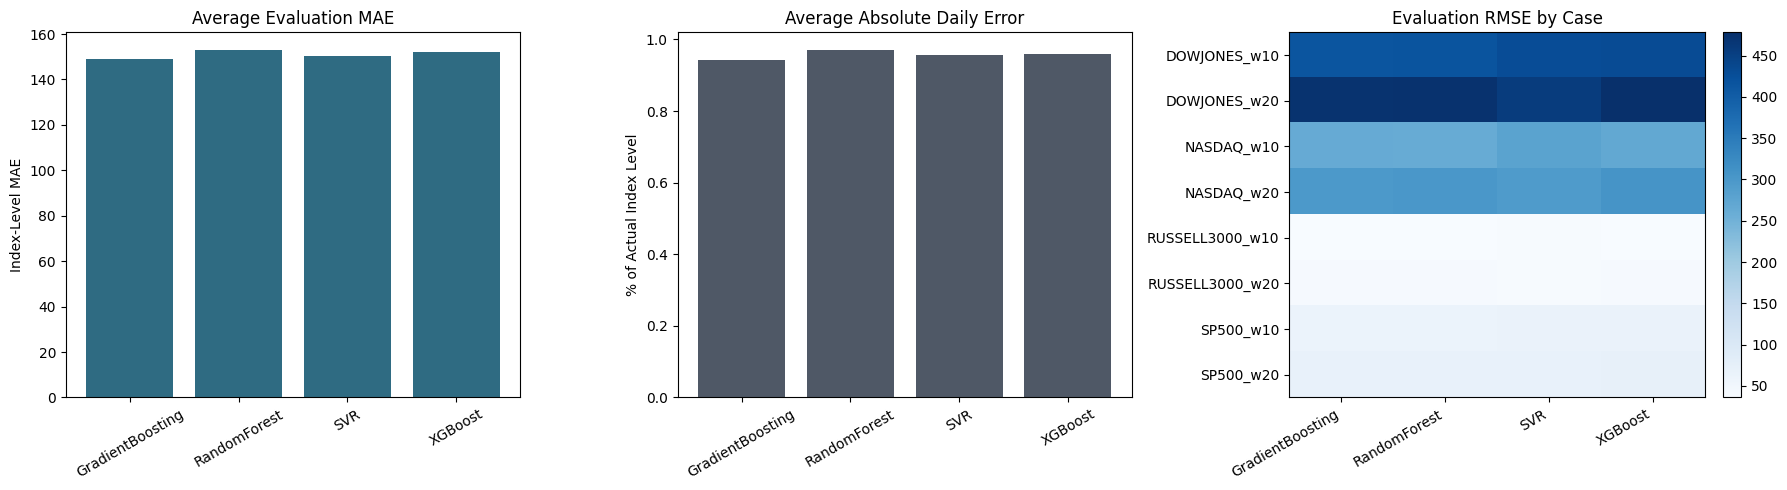

,model,eval_close_MAE,eval_close_RMSE,eval_abs_error_pct_mean,mean_fit_seconds
0,GradientBoosting,148.927577,207.255756,0.944002,0.015877
1,RandomForest,153.106392,207.770829,0.971416,0.029692
2,SVR,150.443863,208.619698,0.956350,0.000612
3,XGBoost,152.277947,212.109116,0.960207,0.010499


model,GradientBoosting,RandomForest,SVR,XGBoost
case_key,,,,
DOWJONES_w10,415.605639,417.720021,429.505814,430.728714
DOWJONES_w20,472.762094,474.126731,456.204494,478.184248
NASDAQ_w10,262.316230,262.083130,279.112697,268.361419
NASDAQ_w20,298.166673,300.312755,294.606273,307.167142
RUSSELL3000_w10,36.469653,36.011111,38.099458,37.150183
RUSSELL3000_w20,40.280979,40.460146,39.242943,40.288323
SP500_w10,62.385822,61.977572,64.995337,64.203792
SP500_w20,70.058959,69.475170,67.190569,70.789107


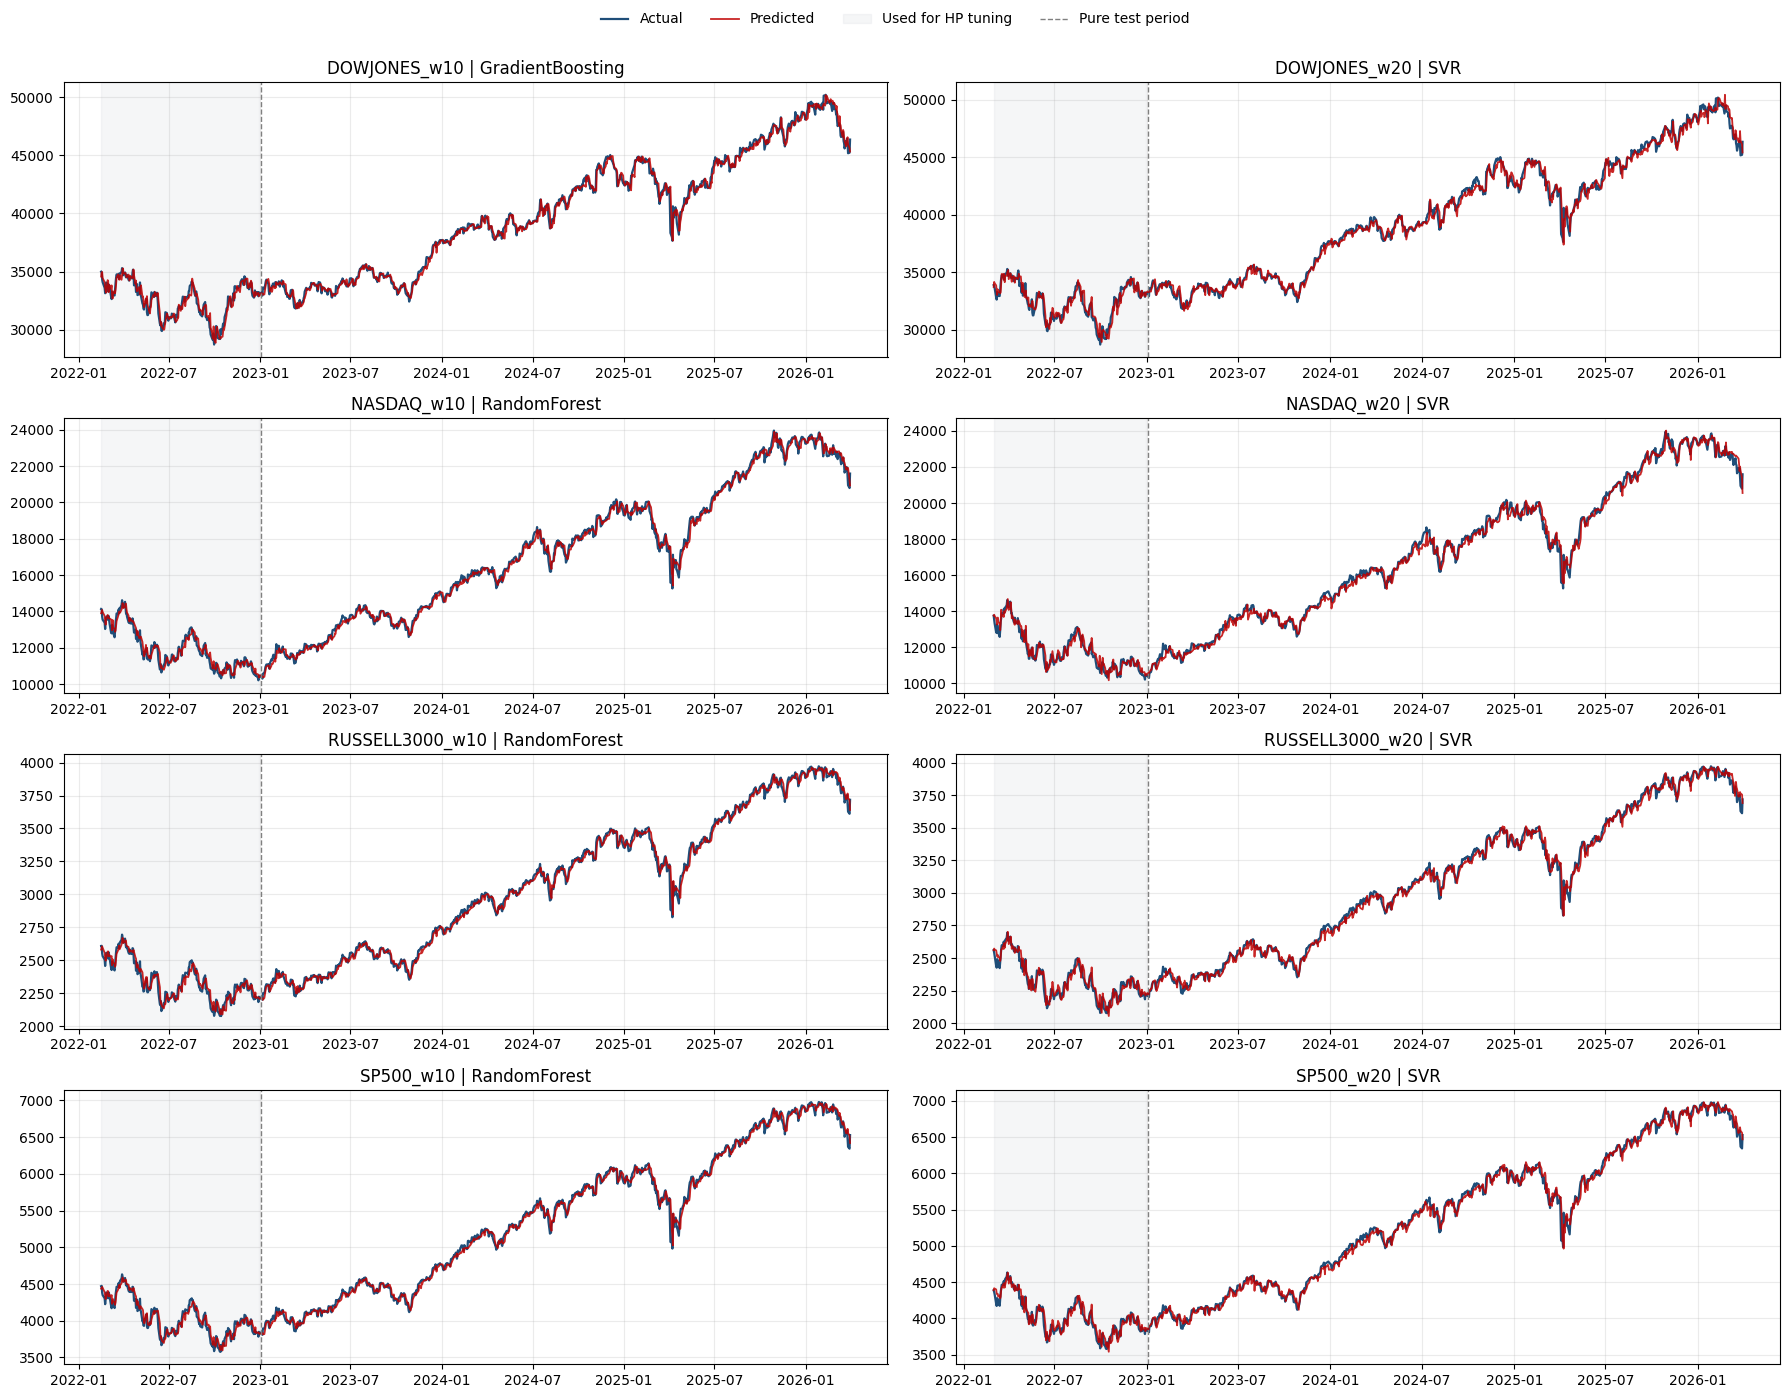

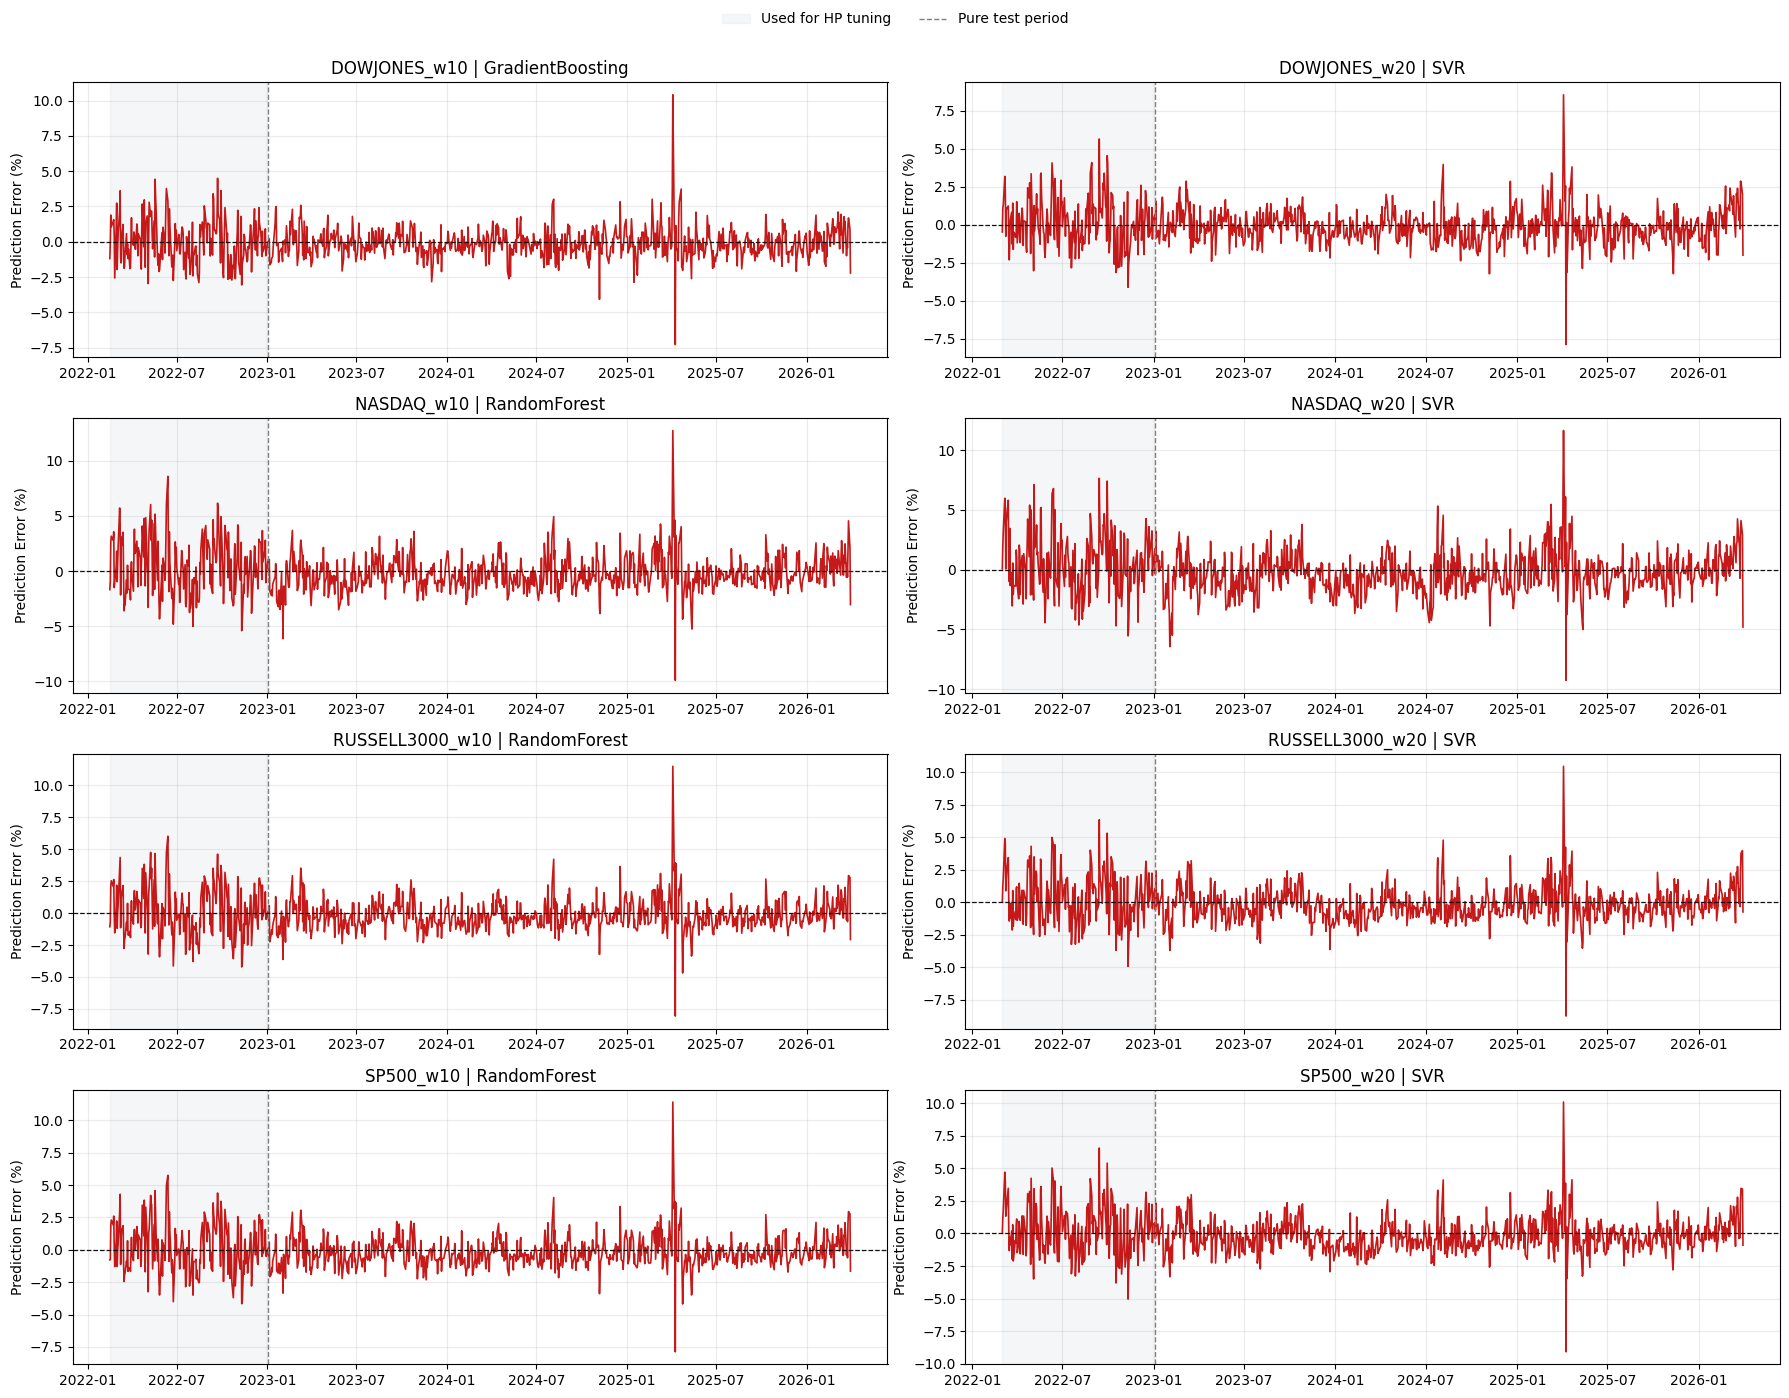

,case_key,model,eval_close_RMSE,eval_close_MAE,eval_abs_error_pct_mean
0,DOWJONES_w10,GradientBoosting,415.605639,297.702201,0.738671
1,DOWJONES_w20,SVR,456.204494,331.706703,0.819812
2,NASDAQ_w10,RandomForest,262.083130,194.393596,1.142976
3,NASDAQ_w20,SVR,294.606273,219.662784,1.289219
4,RUSSELL3000_w10,RandomForest,36.011111,26.182997,0.861438
5,RUSSELL3000_w20,SVR,39.242943,28.849321,0.946755
6,SP500_w10,RandomForest,61.977572,45.223976,0.849016
7,SP500_w20,SVR,67.190569,49.429296,0.926316


[TIMER] build_summary_figures: 2.36s


In [5]:

with timed_step("build_summary_figures"):
    summary_key = "case_key"
    summary_figure_path = FIG_DIR / "01_model_overview.png"
    line_figure_path = FIG_DIR / "02_best_case_level_paths.png"
    error_figure_path = FIG_DIR / "03_best_case_error_pct_paths.png"
    if model_summary.empty:
        print("No completed runs available for summary figures.")
    else:
        avg_metrics = (
            model_summary.groupby("model", as_index=False)[["eval_close_MAE", "eval_close_RMSE", "eval_abs_error_pct_mean", "mean_fit_seconds"]]
            .mean(numeric_only=True)
            .sort_values(["eval_close_RMSE", "eval_abs_error_pct_mean"])
            .reset_index(drop=True)
        )
        heatmap_frame = model_summary.pivot(index=summary_key, columns="model", values="eval_close_RMSE").sort_index()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].bar(avg_metrics["model"], avg_metrics["eval_close_MAE"], color="#2f6b82")
        axes[0].set_title("Average Evaluation MAE")
        axes[0].set_ylabel("Index-Level MAE")
        axes[0].tick_params(axis="x", rotation=30)

        axes[1].bar(avg_metrics["model"], avg_metrics["eval_abs_error_pct_mean"], color="#4f5866")
        axes[1].set_title("Average Absolute Daily Error")
        axes[1].set_ylabel("% of Actual Index Level")
        axes[1].tick_params(axis="x", rotation=30)

        im = axes[2].imshow(heatmap_frame.to_numpy(dtype=float), aspect="auto", cmap="Blues")
        axes[2].set_title("Evaluation RMSE by Case")
        axes[2].set_xticks(range(len(heatmap_frame.columns)))
        axes[2].set_xticklabels(list(heatmap_frame.columns), rotation=30, ha="right")
        axes[2].set_yticks(range(len(heatmap_frame.index)))
        axes[2].set_yticklabels(list(heatmap_frame.index))
        fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

        fig.tight_layout()
        fig.savefig(summary_figure_path, dpi=200, bbox_inches="tight")
        plt.show()
        display(avg_metrics.round(6))
        display(heatmap_frame.round(6))

        best_overall = (
            model_summary.sort_values(
                ["case_key", "eval_close_RMSE", "eval_abs_error_pct_mean", "eval_close_MAE", "mean_fit_seconds"],
                ascending=[True, True, True, True, True],
            )
            .groupby("case_key", as_index=False)
            .head(1)
            .reset_index(drop=True)
        )

        fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=False)
        axes = np.asarray(axes).reshape(-1)
        for ax, (_, best_row) in zip(axes, best_overall.iterrows()):
            pred_frame = pd.read_csv(best_row["prediction_path"])
            pred_frame["test_target_date"] = pd.to_datetime(pred_frame["test_target_date"], errors="coerce")
            pred_frame = pred_frame.sort_values("test_target_date").reset_index(drop=True)
            pred_frame = add_error_columns(pred_frame)
            if PLOT_PREDICTION_SCOPE == "pure_test_only":
                pred_frame = pred_frame.loc[pred_frame["analysis_partition"].eq("pure_test")].copy()
            elif PLOT_PREDICTION_SCOPE != "all_logged":
                raise ValueError(PLOT_PREDICTION_SCOPE)

            ax.plot(pred_frame["test_target_date"], pred_frame["actual_close"], label="Actual", color="#1f4e79", linewidth=1.6)
            ax.plot(pred_frame["test_target_date"], pred_frame["predicted_close"], label="Predicted", color="#c00000", linewidth=1.3, alpha=0.85)

            if PLOT_SHADE_TUNING_PERIOD and PLOT_PREDICTION_SCOPE == "all_logged":
                tune_mask = pred_frame["analysis_partition"].eq("hp_tuning")
                pure_mask = pred_frame["analysis_partition"].eq("pure_test")
                if int(tune_mask.sum()) > 0:
                    tune_end = pred_frame.loc[tune_mask, "test_target_date"].max()
                    tune_start = pred_frame.loc[tune_mask, "test_target_date"].min()
                    ax.axvspan(tune_start, tune_end, color="#d9dde3", alpha=0.25, label=HP_TUNING_LABEL)
                if int(pure_mask.sum()) > 0:
                    pure_start = pred_frame.loc[pure_mask, "test_target_date"].min()
                    ax.axvline(pure_start, color="#808080", linestyle="--", linewidth=1.0, label=PURE_TEST_LABEL)

            ax.set_title(f"{best_row['case_key']} | {best_row['model']}")
            ax.grid(alpha=0.25)
        for ax in axes[len(best_overall):]:
            ax.axis("off")
        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=min(4, len(unique)), frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        fig.savefig(line_figure_path, dpi=200, bbox_inches="tight")
        plt.show()

        fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=False)
        axes = np.asarray(axes).reshape(-1)
        for ax, (_, best_row) in zip(axes, best_overall.iterrows()):
            pred_frame = pd.read_csv(best_row["prediction_path"])
            pred_frame["test_target_date"] = pd.to_datetime(pred_frame["test_target_date"], errors="coerce")
            pred_frame = pred_frame.sort_values("test_target_date").reset_index(drop=True)
            pred_frame = add_error_columns(pred_frame)
            if PLOT_PREDICTION_SCOPE == "pure_test_only":
                pred_frame = pred_frame.loc[pred_frame["analysis_partition"].eq("pure_test")].copy()
            elif PLOT_PREDICTION_SCOPE != "all_logged":
                raise ValueError(PLOT_PREDICTION_SCOPE)

            ax.plot(pred_frame["test_target_date"], pred_frame["error_pct"], color="#c00000", linewidth=1.2, alpha=0.9)
            ax.axhline(0.0, color="#111111", linestyle="--", linewidth=0.9)

            if PLOT_SHADE_TUNING_PERIOD and PLOT_PREDICTION_SCOPE == "all_logged":
                tune_mask = pred_frame["analysis_partition"].eq("hp_tuning")
                pure_mask = pred_frame["analysis_partition"].eq("pure_test")
                if int(tune_mask.sum()) > 0:
                    tune_end = pred_frame.loc[tune_mask, "test_target_date"].max()
                    tune_start = pred_frame.loc[tune_mask, "test_target_date"].min()
                    ax.axvspan(tune_start, tune_end, color="#d9dde3", alpha=0.25, label=HP_TUNING_LABEL)
                if int(pure_mask.sum()) > 0:
                    pure_start = pred_frame.loc[pure_mask, "test_target_date"].min()
                    ax.axvline(pure_start, color="#808080", linestyle="--", linewidth=1.0, label=PURE_TEST_LABEL)

            ax.set_title(f"{best_row['case_key']} | {best_row['model']}")
            ax.set_ylabel("Prediction Error (%)")
            ax.grid(alpha=0.25)
        for ax in axes[len(best_overall):]:
            ax.axis("off")
        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=min(4, len(unique)), frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        fig.savefig(error_figure_path, dpi=200, bbox_inches="tight")
        plt.show()
        display(best_overall[["case_key", "model", "eval_close_RMSE", "eval_close_MAE", "eval_abs_error_pct_mean"]].round(6))
